# 🌙 Low-Light Image Enhancement & Object Detection
### Zero-DCE + YOLOv8 Pipeline

---

This notebook implements a complete **unsupervised low-light image enhancement** pipeline using the **Zero-DCE (Zero-Reference Deep Curve Estimation)** model, followed by **YOLOv8 object detection** on the enhanced output.

**The pipeline has 5 phases:**

| Phase | Description |
|-------|-------------|
| **Phase 1** | Environment Setup & Imports |
| **Phase 2** | Dataset Loading & Exploratory Analysis |
| **Phase 3** | Model Architecture & Loss Functions |
| **Phase 4** | Training (auto-skipped if model already saved) |
| **Phase 5** | Inference, YOLO Detection & Interactive GUI |

---

---
## 🏋️ Phase 4 — Training (Smart Resume)

### Cell 9 | Train or Load Saved Model
**Automatically skips training** if `best_zero_dce.pth` already exists on disk.
If the model has never been trained, it trains for the configured number of epochs and saves the best checkpoint.

In [17]:
model           = DCENet().to(device)
spatial_loss_fn = SpatialConsistencyLoss()

# ── Check if a saved model already exists ──────────────────────────────────
if os.path.exists(MODEL_PATH):
    print(f"✅ Saved model found at '{MODEL_PATH}' — loading weights, skipping training.")
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()
    loss_log = None   # no training log available when loading
else:
    print(f"⚠️  No saved model found. Starting training for {EPOCHS} epochs...")
    optimizer = optim.Adam(model.parameters(), lr=LR)

    loss_log = {
        "total_loss": [], "illumination_smoothness_loss": [],
        "spatial_constancy_loss": [], "color_constancy_loss": [], "exposure_loss": []
    }
    best_loss = float("inf")

    for epoch in range(EPOCHS):
        model.train()
        total, smooth, spatial, color, exposure = 0, 0, 0, 0, 0

        for img in train_loader:
            img      = img.to(device)
            r        = model(img)
            enhanced = enhance(img, r)

            l_s  = 200 * smoothness_loss(r)
            l_sp = spatial_loss_fn(enhanced, img)
            l_c  = 5   * torch.mean(color_constancy(enhanced))
            l_e  = 10  * exposure_loss(enhanced)
            loss = l_s + l_sp + l_c + l_e

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total    += loss.item()
            smooth   += l_s.item()
            spatial  += l_sp.item()
            color    += l_c.item()
            exposure += l_e.item()

        n = len(train_loader)
        loss_log["total_loss"].append(total / n)
        loss_log["illumination_smoothness_loss"].append(smooth / n)
        loss_log["spatial_constancy_loss"].append(spatial / n)
        loss_log["color_constancy_loss"].append(color / n)
        loss_log["exposure_loss"].append(exposure / n)

        print(f"Epoch [{epoch+1:>3}/{EPOCHS}]  Loss: {total/n:.4f}")

        if total / n < best_loss:
            best_loss = total / n
            torch.save(model.state_dict(), MODEL_PATH)
            print(f"              💾 New best model saved (loss={best_loss:.4f})")

    model.eval()
    print(f"\n✅ Training complete. Best loss: {best_loss:.4f}")

✅ Saved model found at 'best_zero_dce.pth' — loading weights, skipping training.


C:\Users\dayan\AppData\Local\Temp\ipykernel_16120\2743466957.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=de

### Cell 10 | Training Loss Curves
Plot the loss curves to inspect convergence. This cell is skipped automatically if a pre-trained model was loaded.

In [18]:
if loss_log is not None:
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()
    names = list(loss_log.keys())

    for i, name in enumerate(names):
        axes[i].plot(loss_log[name], color="steelblue", linewidth=1.5)
        axes[i].set_title(name.replace("_", " ").title(), fontweight="bold")
        axes[i].set_xlabel("Epoch")
        axes[i].set_ylabel("Loss")
        axes[i].grid(True, linestyle="--", alpha=0.5)

    # hide the 6th empty subplot
    axes[-1].set_visible(False)
    plt.suptitle("Training Loss Curves — Zero-DCE", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️  Pre-trained model was loaded — no training log to display.")

ℹ️  Pre-trained model was loaded — no training log to display.


In [19]:
import sys
import subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "ultralytics", "--quiet"], check=True)
print("✅ Ultralytics (YOLOv8) ready")

✅ Ultralytics (YOLOv8) ready


### Cell 12 | Load YOLOv8 Model
Loads the **YOLOv8-nano** model (fastest variant, ~6 MB). Weights are downloaded automatically on first run.

In [20]:
import cv2
from ultralytics import YOLO

yolo_model = YOLO("yolov8s.pt")   # upgraded from nano → small, better accuracy
print("✅ YOLOv8 small loaded")

✅ YOLOv8 small loaded


### Cell 13 | Inference & Detection Helper Functions
- `infer()` — runs Zero-DCE on any image path and returns (original PIL, enhanced numpy)
- `detect_on_enhanced()` — runs YOLOv8 on the enhanced numpy array and returns annotated RGB image

In [21]:
def infer(path_or_pil):
    img = Image.open(path_or_pil).convert("RGB") if isinstance(path_or_pil, str) else path_or_pil

    tfm = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor()
    ])
    x = tfm(img).unsqueeze(0).to(device)
    with torch.no_grad():
        r   = model(x)
        out = enhance(x, r)

    enhanced_small = out.squeeze().cpu().permute(1, 2, 0).numpy()
    enhanced_small = np.clip(enhanced_small, 0, 1)

    # Resize enhanced output back to original resolution for better YOLO detection
    orig_w, orig_h = img.size
    enhanced_fullres = np.array(
        Image.fromarray((enhanced_small * 255).astype(np.uint8)).resize((orig_w, orig_h), Image.LANCZOS)
    ) / 255.0

    return img, enhanced_fullres


def detect_on_enhanced(enhanced_np):
    img_uint8 = np.ascontiguousarray((enhanced_np * 255).astype(np.uint8))

    # conf lowered to 0.15, imgsz=640 forces YOLO's optimal input resolution
    results       = yolo_model(img_uint8, conf=0.15, imgsz=640, verbose=False)
    annotated_bgr = results[0].plot()
    annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)
    return annotated_rgb, results[0]

print("✅ infer() and detect_on_enhanced() updated")

✅ infer() and detect_on_enhanced() updated


### Cell 14 | Batch Inference on Test Set
Runs the full pipeline (enhance → detect → visualize) on the first 5 test images.

🔍 Processing 5 test images...



C:\Users\dayan\AppData\Local\Temp\ipykernel_16120\1129979514.py:19: UserWarning: Glyph 128194 (\N{OPEN FILE FOLDER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dayan\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128194 (\N{OPEN FILE FOLDER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


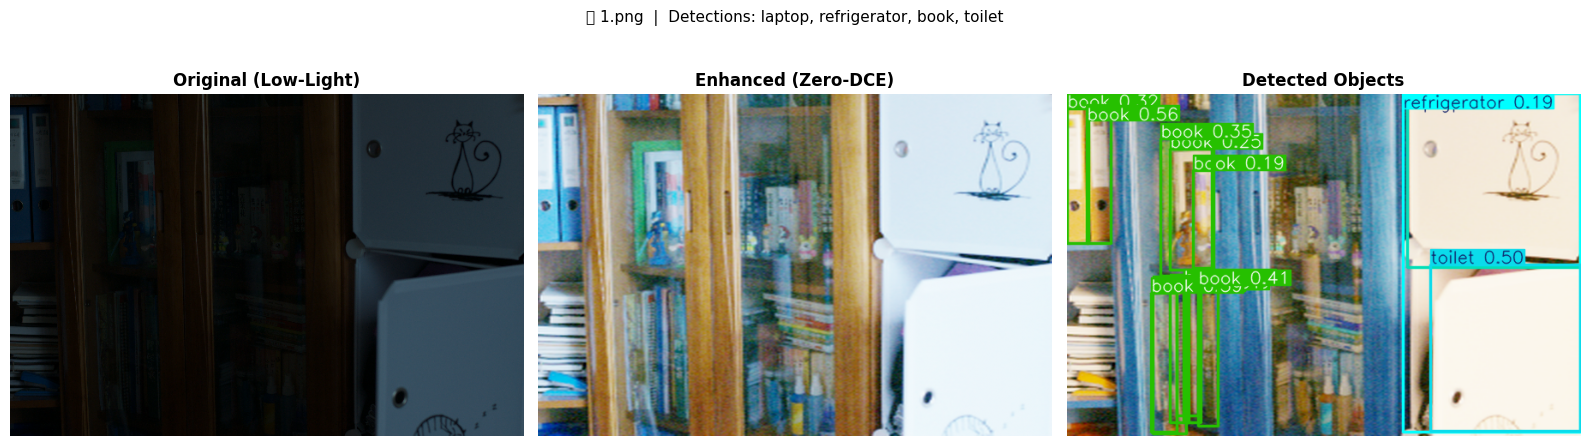

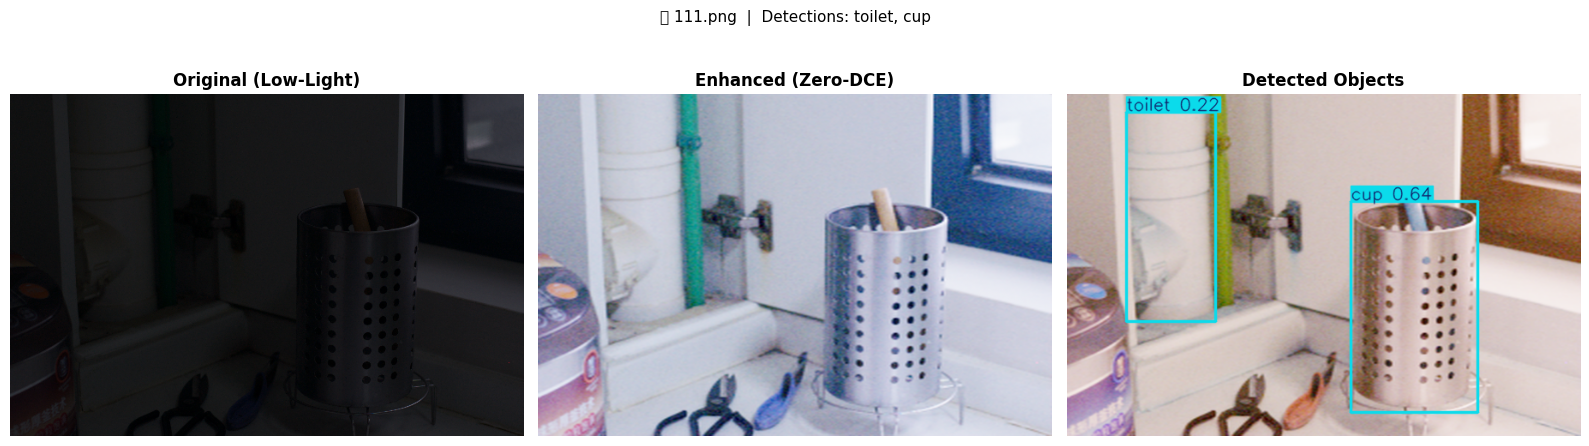

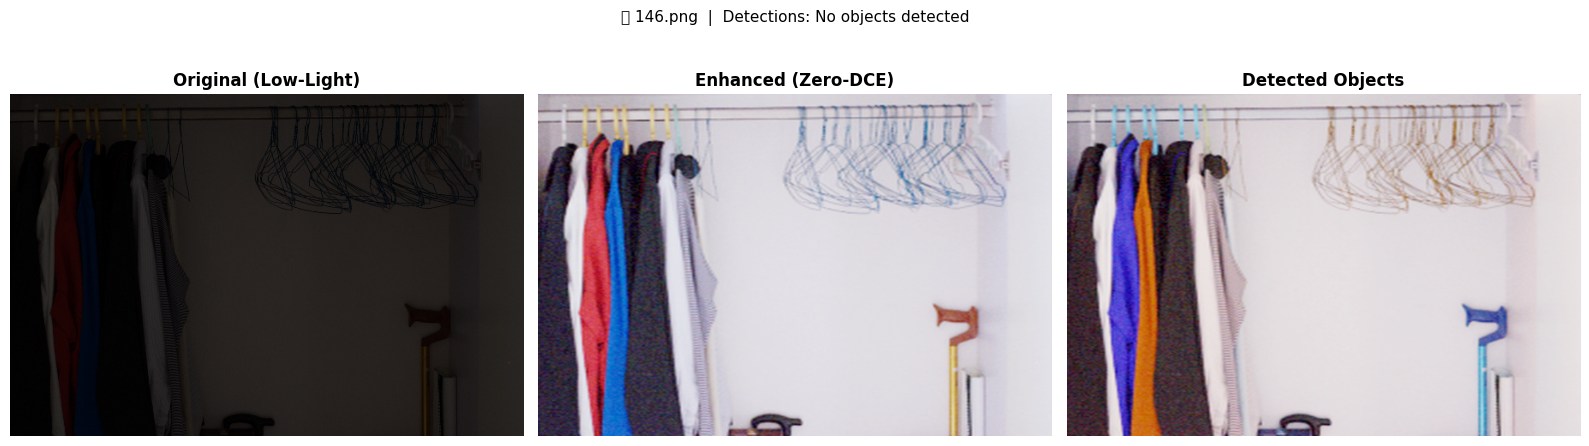

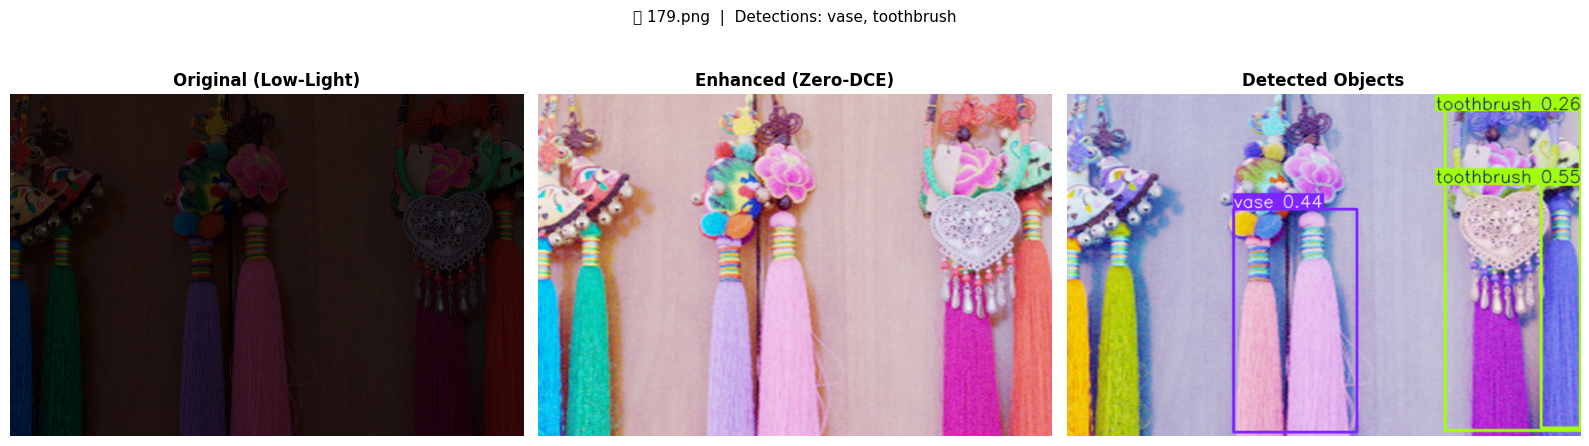

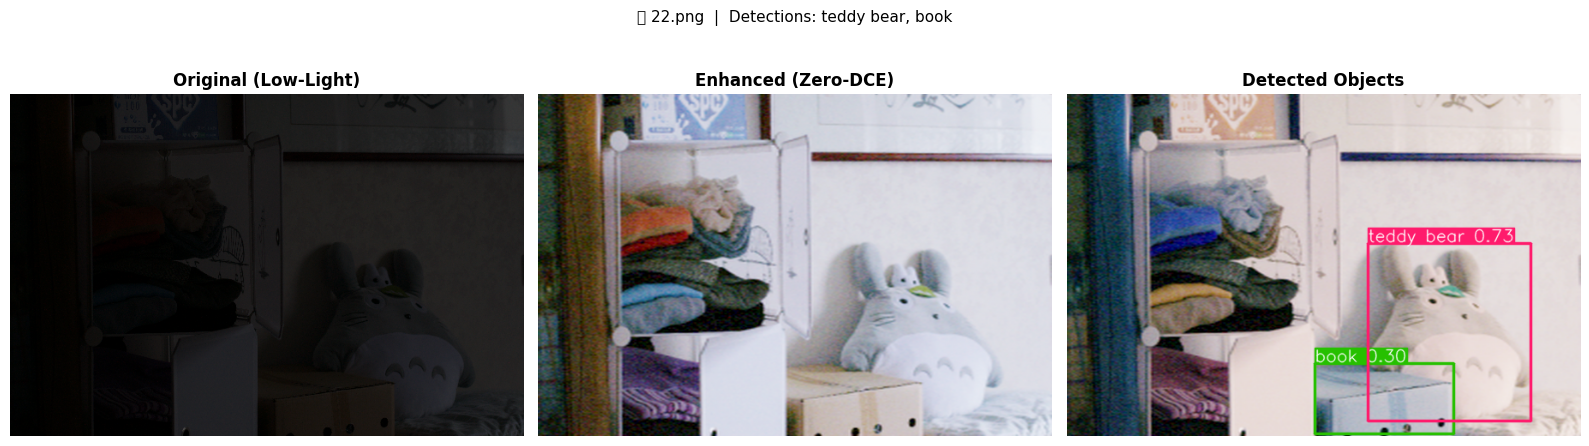

In [22]:
test_files = glob.glob(TEST_DIR + "/*.png")
print(f"🔍 Processing {min(5, len(test_files))} test images...\n")

for f in test_files[:5]:
    orig_pil, enhanced_np = infer(f)
    annotated, results    = detect_on_enhanced(enhanced_np)

    detected_labels = []
    if results.boxes is not None and len(results.boxes):
        class_ids       = results.boxes.cls.cpu().numpy().astype(int)
        detected_labels = [yolo_model.names[c] for c in class_ids]
    label_str = ", ".join(set(detected_labels)) if detected_labels else "No objects detected"

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].imshow(orig_pil);     axes[0].set_title("Original (Low-Light)",  fontweight="bold"); axes[0].axis("off")
    axes[1].imshow(enhanced_np);  axes[1].set_title("Enhanced (Zero-DCE)",   fontweight="bold"); axes[1].axis("off")
    axes[2].imshow(annotated);    axes[2].set_title(f"Detected Objects",      fontweight="bold"); axes[2].axis("off")
    plt.suptitle(f"📂 {os.path.basename(f)}  |  Detections: {label_str}", fontsize=11)
    plt.tight_layout()
    plt.show()

### Cell 15 | Save Batch Results & Detection Log
Saves enhanced + annotated images and a JSON detection log to `results_yolo/`.

In [23]:
os.makedirs("results_yolo", exist_ok=True)
detection_summary = {}

for i, f in enumerate(test_files):
    _, enhanced_np        = infer(f)
    annotated, results    = detect_on_enhanced(enhanced_np)

    Image.fromarray(annotated).save(f"results_yolo/annotated_{i}.png")
    Image.fromarray((enhanced_np * 255).astype(np.uint8)).save(f"results_yolo/enhanced_{i}.png")

    detections = []
    if results.boxes is not None and len(results.boxes):
        for box, conf, cls in zip(
            results.boxes.xyxy.cpu().numpy(),
            results.boxes.conf.cpu().numpy(),
            results.boxes.cls.cpu().numpy()
        ):
            detections.append({
                "class": yolo_model.names[int(cls)],
                "confidence": round(float(conf), 3),
                "bbox_xyxy": [round(float(v), 1) for v in box]
            })

    detection_summary[os.path.basename(f)] = detections
    print(f"[{i+1:>2}/{len(test_files)}] {os.path.basename(f)} → {len(detections)} object(s)")

with open("results_yolo/detections_log.json", "w") as jf:
    json.dump(detection_summary, jf, indent=2)

print("\n✅ All results saved to /results_yolo/")
print("✅ Detection log saved to /results_yolo/detections_log.json")

[ 1/15] 1.png → 14 object(s)
[ 2/15] 111.png → 2 object(s)
[ 3/15] 146.png → 0 object(s)
[ 4/15] 179.png → 3 object(s)
[ 5/15] 22.png → 2 object(s)
[ 6/15] 23.png → 3 object(s)
[ 7/15] 493.png → 6 object(s)
[ 8/15] 547.png → 2 object(s)
[ 9/15] 55.png → 0 object(s)
[10/15] 665.png → 5 object(s)
[11/15] 669.png → 1 object(s)
[12/15] 748.png → 9 object(s)
[13/15] 778.png → 0 object(s)
[14/15] 780.png → 0 object(s)
[15/15] 79.png → 6 object(s)

✅ All results saved to /results_yolo/
✅ Detection log saved to /results_yolo/detections_log.json


### Cell 16 | Detection Summary Statistics
Count and visualize the object classes detected across the entire test set.

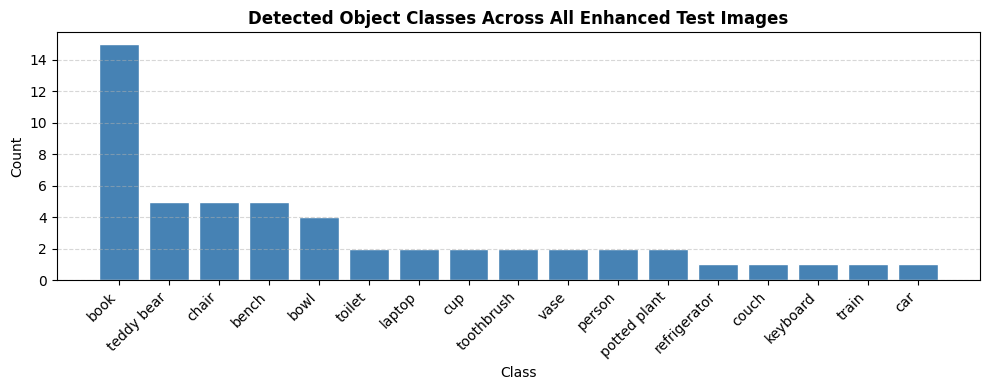


📊 Total detections : 53
📦 Unique classes   : 17

   book                   15
   teddy bear             5
   chair                  5
   bench                  5
   bowl                   4
   toilet                 2
   laptop                 2
   cup                    2
   toothbrush             2
   vase                   2
   person                 2
   potted plant           2
   refrigerator           1
   couch                  1
   keyboard               1
   train                  1
   car                    1


In [24]:
from collections import Counter

all_classes = [d["class"] for dets in detection_summary.values() for d in dets]

if all_classes:
    class_counts  = Counter(all_classes)
    labels_sorted = sorted(class_counts, key=class_counts.get, reverse=True)
    counts_sorted = [class_counts[l] for l in labels_sorted]

    plt.figure(figsize=(10, 4))
    plt.bar(labels_sorted, counts_sorted, color="steelblue", edgecolor="white")
    plt.title("Detected Object Classes Across All Enhanced Test Images", fontweight="bold")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()

    print(f"\n📊 Total detections : {len(all_classes)}")
    print(f"📦 Unique classes   : {len(class_counts)}")
    print()
    for cls, cnt in class_counts.most_common():
        print(f"   {cls:<22} {cnt}")
else:
    print("⚠️  No objects detected. Try lowering conf=0.25 → conf=0.10 in detect_on_enhanced()")